# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Wajiha-Waqar/FlyRankInternship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Capstone — Content Refresh Opportunity Scoring

This capstone develops and evaluates a repeatable content-refresh opportunity ranking using real FlyRank search and analytics data.

The objective is not to predict Google's algorithm or automate editorial decisions. The objective is to identify pages that appear worth human review first, using signals available before a future performance outcome.

The workflow covers:

1. Research question and decision framing.
2. Data construction and temporal alignment.
3. Leakage-aware feature engineering.
4. Baseline and machine-learning ranking.
5. Time-aware evaluation on a future month.
6. Ranked recommendations with reason codes.
7. Limitations and reproducibility artifacts.

## 0. Setup

### What this section does

This section creates a reproducible environment for the analysis.

The notebook does not assume that variables from previous notebooks already exist. All packages, paths, configuration, data access, transformations, models, and evaluation functions are defined here.

The analysis uses the FlyRank warehouse through DuckDB and Hugging Face. The access token is read from the notebook environment rather than written into the notebook.

The notebook uses January through April 2026 to construct two historical training periods and one future evaluation period:

- January → February: training period
- February → March: training period
- March → April: future test period

The final test period is kept separate from model development.

In [1]:
# ============================================================
# 0. SETUP — INSTALL AND IMPORT
# ============================================================

!pip -q install duckdb pyarrow pandas numpy scikit-learn matplotlib

import os
import json
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score

RANDOM_STATE = 42

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("Environment ready.")

Environment ready.


In [2]:
# ============================================================
# CREATE OUTPUT DIRECTORIES
# ============================================================

OUTPUT_DIR = Path("work/outputs")
FIGURE_DIR = Path("work/figures")
METRIC_DIR = Path("work/metrics")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)

print("Output directories ready:")
print(" -", OUTPUT_DIR)
print(" -", FIGURE_DIR)
print(" -", METRIC_DIR)

Output directories ready:
 - work/outputs
 - work/figures
 - work/metrics


In [3]:
# ============================================================
# HUGGING FACE / DUCKDB CONNECTION
# ============================================================

from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError(
        "HF_TOKEN was not found. Add your Hugging Face read token "
        "to Google Colab Secrets using the name HF_TOKEN."
    )

con = duckdb.connect()

con.sql("INSTALL httpfs;")
con.sql("LOAD httpfs;")

con.sql(f"""
CREATE OR REPLACE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN '{HF_TOKEN}'
);
""")

print("Hugging Face connection configured.")

Hugging Face connection configured.


## 1. Question

### Research question

Can March-only, non-label-derived search and engagement signals rank content that subsequently meets a predefined refresh-review condition in April?

### Decision supported

The intended decision is:

> Which pages should a human content or SEO reviewer inspect first?

The output is therefore a ranking and triage system, not an automated publishing or content-management system.

### Why this question matters

Content teams often have more pages than they can review at the same time. A ranking can help allocate limited review attention toward pages that appear more worthy of investigation.

The experiment evaluates whether historical signals can provide useful prioritization evidence while explicitly avoiding claims about Google's ranking algorithm or causal effects of refreshing content.

### Primary hypothesis

Pages with weaker search visibility or weaker engagement-related signals may be more likely to meet the defined future refresh-review outcome.

This is an empirical hypothesis, not an assumption that any single signal causes the outcome.

### Success criterion

The learned ranking should be compared with the fixed baseline on the same future test set.

The primary metrics are:

- Precision@20
- Precision@50
- Precision@100
- Average Precision

The positive-class base rate will always be reported alongside these metrics.

## 2. Data

### Dataset

This analysis uses the FlyRank internship warehouse release:

`hf://datasets/FlyRank/internship-warehouse`

The warehouse contains daily content-performance observations at approximately:

> report_date × client × content

The analysis uses the `fact_content_daily_performance` table.

### Date windows

Four monthly partitions are used:

- January 2026
- February 2026
- March 2026
- April 2026

These create three month-to-month observations:

| Feature month | Outcome month | Role |
|---|---|---|
| January | February | Model development |
| February | March | Model development |
| March | April | Future test |

### Population

The modeling population consists of content with usable search data and a matching observation in the following month.

This means the study does not represent every possible content item. It represents content that is observable in the relevant feature and outcome windows.

### Exclusions

The model excludes:

- future-window variables from the feature set;
- direct components of the target definition;
- client and content identifiers as predictive features;
- data unavailable before the prediction month.

The final-month outcome is used only for evaluation after model development.

### Public-safety rule

The notebook does not publish client names, domains, URLs, private queries, credentials, or raw client-level exports.

In [4]:
# ============================================================
# VERIFY WAREHOUSE COVERAGE
# ============================================================

warehouse_check = con.execute("""
SELECT
    COUNT(*) AS row_count,
    MIN(report_date) AS min_date,
    MAX(report_date) AS max_date
FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet',
    hive_partitioning = true
)
""").df()

warehouse_check

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,row_count,min_date,max_date
0,78835655,2025-01-27,2026-06-30


In [5]:
# ============================================================
# GRAIN CHECK
# ============================================================

grain_probe = con.execute("""
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    COUNT(*) AS row_count
FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
)
GROUP BY
    report_date,
    client_hash_id,
    content_hash_id
HAVING COUNT(*) > 1
LIMIT 5
""").df()

print("Duplicate rows at expected daily grain:", len(grain_probe))

if len(grain_probe) > 0:
    display(grain_probe)
else:
    print("No duplicate daily-grain rows detected.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Duplicate rows at expected daily grain: 0
No duplicate daily-grain rows detected.


In [6]:
# ============================================================
# MONTHLY AGGREGATION FUNCTION
# ============================================================

def load_monthly_panel(month):
    """
    Load one warehouse month and aggregate daily observations
    to client × content × month.

    The target-defining GSC fields are retained for label creation,
    but they are NOT used as model features later.
    """

    query = f"""
    WITH daily AS (
        SELECT
            report_date,
            client_hash_id,
            content_hash_id,

            COALESCE(gsc_impressions, 0) AS gsc_impressions,
            COALESCE(gsc_clicks, 0) AS gsc_clicks,
            COALESCE(gsc_avg_position, 0) AS gsc_avg_position,

            COALESCE(ga4_pageviews, 0) AS ga4_pageviews,
            COALESCE(ga4_sessions, 0) AS ga4_sessions,
            COALESCE(ga4_users, 0) AS ga4_users,
            COALESCE(ga4_engaged_sessions, 0) AS ga4_engaged_sessions,
            COALESCE(ga4_total_engagement_sec, 0) AS ga4_total_engagement_sec,

            COALESCE(sessions_organic, 0) AS sessions_organic,
            COALESCE(sessions_direct, 0) AS sessions_direct,
            COALESCE(sessions_referral, 0) AS sessions_referral,
            COALESCE(sessions_social, 0) AS sessions_social,
            COALESCE(sessions_paid, 0) AS sessions_paid,
            COALESCE(sessions_ai, 0) AS sessions_ai,

            COALESCE(ai_chatgpt, 0) AS ai_chatgpt,
            COALESCE(ai_perplexity, 0) AS ai_perplexity,
            COALESCE(ai_gemini, 0) AS ai_gemini,
            COALESCE(ai_copilot, 0) AS ai_copilot,
            COALESCE(ai_claude, 0) AS ai_claude,
            COALESCE(ai_meta, 0) AS ai_meta,
            COALESCE(ai_other, 0) AS ai_other,

            COALESCE(scroll_events, 0) AS scroll_events,

            COALESCE(ga4_data_available, FALSE) AS ga4_data_available
        FROM read_parquet(
            'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month={month}/*.parquet'
        )
        WHERE gsc_data_available IS TRUE
    )

    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS gsc_impressions,
        SUM(gsc_clicks) AS gsc_clicks,

        SUM(
            CASE
                WHEN gsc_avg_position > 0
                THEN gsc_avg_position * gsc_impressions
                ELSE 0
            END
        )
        /
        NULLIF(
            SUM(
                CASE
                    WHEN gsc_avg_position > 0
                    THEN gsc_impressions
                    ELSE 0
                END
            ),
            0
        ) AS gsc_avg_position,

        SUM(ga4_pageviews) AS ga4_pageviews,
        SUM(ga4_sessions) AS ga4_sessions,
        SUM(ga4_users) AS ga4_users,
        SUM(ga4_engaged_sessions) AS ga4_engaged_sessions,
        SUM(ga4_total_engagement_sec) AS ga4_total_engagement_sec,

        SUM(sessions_organic) AS sessions_organic,
        SUM(sessions_direct) AS sessions_direct,
        SUM(sessions_referral) AS sessions_referral,
        SUM(sessions_social) AS sessions_social,
        SUM(sessions_paid) AS sessions_paid,
        SUM(sessions_ai) AS sessions_ai,

        SUM(ai_chatgpt) AS ai_chatgpt,
        SUM(ai_perplexity) AS ai_perplexity,
        SUM(ai_gemini) AS ai_gemini,
        SUM(ai_copilot) AS ai_copilot,
        SUM(ai_claude) AS ai_claude,
        SUM(ai_meta) AS ai_meta,
        SUM(ai_other) AS ai_other,

        SUM(scroll_events) AS scroll_events,

        MAX(CASE WHEN ga4_data_available THEN 1 ELSE 0 END)
            AS ga4_data_available,

        '{month}' AS feature_month

    FROM daily

    GROUP BY
        client_hash_id,
        content_hash_id
    """

    return con.execute(query).df()


months = [
    "2026-01",
    "2026-02",
    "2026-03",
    "2026-04"
]

monthly = {}

for month in months:
    print(f"Loading {month}...")
    monthly[month] = load_monthly_panel(month)
    print("Rows:", len(monthly[month]))

print("Finished.")

Loading 2026-01...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 121544
Loading 2026-02...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 153559
Loading 2026-03...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 176738
Loading 2026-04...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 194760
Finished.


In [7]:
# ============================================================
# DERIVED MONTHLY SIGNALS
# ============================================================

def add_monthly_signals(df):
    df = df.copy()

    df["organic_session_share"] = np.where(
        df["ga4_sessions"] > 0,
        df["sessions_organic"] / df["ga4_sessions"],
        np.nan
    )

    df["engaged_session_rate"] = np.where(
        df["ga4_sessions"] > 0,
        df["ga4_engaged_sessions"] / df["ga4_sessions"],
        np.nan
    )

    df["avg_engagement_sec_per_session"] = np.where(
        df["ga4_sessions"] > 0,
        df["ga4_total_engagement_sec"] / df["ga4_sessions"],
        np.nan
    )

    df["ai_session_share"] = np.where(
        df["ga4_sessions"] > 0,
        df["sessions_ai"] / df["ga4_sessions"],
        np.nan
    )

    df["scroll_events_per_session"] = np.where(
        df["ga4_sessions"] > 0,
        df["scroll_events"] / df["ga4_sessions"],
        np.nan
    )

    df["ctr"] = np.where(
        df["gsc_impressions"] > 0,
        df["gsc_clicks"] / df["gsc_impressions"],
        np.nan
    )

    return df


for month in monthly:
    monthly[month] = add_monthly_signals(monthly[month])

print(monthly["2026-03"].head())

            client_hash_id           content_hash_id  gsc_impressions  gsc_clicks  gsc_avg_position  ga4_pageviews  ga4_sessions  ga4_users  \
0  client_62f4a7e64f5e0096  content_2e6360ad20fd7107            899.0         1.0          5.924208            0.0           0.0        0.0   
1  client_62f4a7e64f5e0096  content_ac8663da7484669a             34.0         0.0          7.214286            0.0           0.0        0.0   
2  client_62f4a7e64f5e0096  content_d49a012dcb924e31            329.0         0.0          5.136778            0.0           0.0        0.0   
3  client_62f4a7e64f5e0096  content_614baf2af4330bd7            772.0         1.0          4.818653            0.0           0.0        0.0   
4  client_62f4a7e64f5e0096  content_4a1ca0fa5c177e0c             14.0         0.0          5.000000            0.0           0.0        0.0   

   ga4_engaged_sessions  ga4_total_engagement_sec  sessions_organic  sessions_direct  sessions_referral  sessions_social  sessions_paid  sess

### Target definition

The future outcome is deliberately kept consistent with the Week-5 research question so that the capstone remains a continuation rather than a completely unrelated project.

A page receives `refresh_outcome = 1` when:

1. it had at least 100 March impressions;
2. it had measurable March CTR; and
3. April CTR was at least 20% lower than March CTR.

Formally, the outcome is:

> March impressions ≥ 100 AND March CTR > 0 AND April CTR / March CTR ≤ 0.80.

The first two conditions define the eligible population for the outcome. The third condition represents the future deterioration event.

Crucially, the March impressions, March clicks, and March CTR variables are **not supplied to the model as features**.

This prevents the Week-5 label-derived leakage identified during the Week-6 validation audit.

In [8]:
# ============================================================
# BUILD MONTH-TO-MONTH PANELS
# ============================================================

def build_pair(feature_month, outcome_month):
    feature_df = monthly[feature_month].copy()
    outcome_df = monthly[outcome_month][
        [
            "client_hash_id",
            "content_hash_id",
            "gsc_impressions",
            "gsc_clicks",
            "ctr"
        ]
    ].copy()

    outcome_df = outcome_df.rename(
        columns={
            "gsc_impressions": "gsc_impressions_next",
            "gsc_clicks": "gsc_clicks_next",
            "ctr": "ctr_next"
        }
    )

    pair = feature_df.merge(
        outcome_df,
        on=["client_hash_id", "content_hash_id"],
        how="inner"
    )

    pair["refresh_outcome"] = (
        (pair["gsc_impressions"] >= 100)
        &
        (pair["ctr"] > 0)
        &
        (pair["ctr_next"] <= 0.80 * pair["ctr"])
    ).astype(int)

    pair["ctr_change_pct"] = np.where(
        pair["ctr"] > 0,
        (pair["ctr_next"] - pair["ctr"]) / pair["ctr"],
        np.nan
    )

    return pair


jan_feb = build_pair("2026-01", "2026-02")
feb_mar = build_pair("2026-02", "2026-03")
mar_apr = build_pair("2026-03", "2026-04")

print("January → February:", jan_feb.shape)
print("February → March:", feb_mar.shape)
print("March → April:", mar_apr.shape)

print("\nMarch → April target:")
print(mar_apr["refresh_outcome"].value_counts())
print("\nBase rate:")
print(mar_apr["refresh_outcome"].mean())

January → February: (110867, 37)
February → March: (134238, 37)
March → April: (158549, 37)

March → April target:
refresh_outcome
0    120913
1     37636
Name: count, dtype: int64

Base rate:
0.23737771919091258


In [9]:
# ============================================================
# DATA QUALITY / TARGET AUDIT
# ============================================================

audit = pd.DataFrame({
    "period": [
        "Jan → Feb",
        "Feb → Mar",
        "Mar → Apr"
    ],
    "rows": [
        len(jan_feb),
        len(feb_mar),
        len(mar_apr)
    ],
    "clients": [
        jan_feb["client_hash_id"].nunique(),
        feb_mar["client_hash_id"].nunique(),
        mar_apr["client_hash_id"].nunique()
    ],
    "positive_rate": [
        jan_feb["refresh_outcome"].mean(),
        feb_mar["refresh_outcome"].mean(),
        mar_apr["refresh_outcome"].mean()
    ]
})

audit

,period,rows,clients,positive_rate
0,Jan → Feb,110867,34,0.175472
1,Feb → Mar,134238,42,0.197507
2,Mar → Apr,158549,46,0.237378


### Population note

The inner join between consecutive months means that the model evaluates content observed in both the feature and outcome windows.

This is an intentional analytical population choice, but it creates a survivorship/availability limitation: content without a matching future observation is not represented in the outcome evaluation.

The result should therefore be interpreted as evidence about the observed month-to-month panel, not every page that could exist in a production content inventory.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 3. Methodology

### Feature design

The model uses only information available during the feature month.

The following variables are deliberately excluded:

- `gsc_impressions`
- `gsc_clicks`
- `ctr`

These variables participate directly or indirectly in the target definition and therefore would recreate the label-derived leakage discovered in Week 6.

The model instead uses search visibility, analytics engagement, traffic-source, AI-referral, and measurement-availability signals.

Client and content identifiers are used only for joins and validation logic, never as predictive features.

In [10]:
# ============================================================
# CLEAN FEATURE SET
# ============================================================

FEATURE_COLS = [
    "gsc_avg_position",

    "ga4_pageviews",
    "ga4_sessions",
    "ga4_users",
    "ga4_engaged_sessions",
    "ga4_total_engagement_sec",

    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid",
    "sessions_ai",

    "ai_chatgpt",
    "ai_perplexity",
    "ai_gemini",
    "ai_copilot",
    "ai_claude",
    "ai_meta",
    "ai_other",

    "scroll_events",

    "ga4_data_available",

    "organic_session_share",
    "engaged_session_rate",
    "avg_engagement_sec_per_session",
    "ai_session_share",
    "scroll_events_per_session"
]

# Confirm none of the label-derived fields slipped into the feature set.
FORBIDDEN_FEATURES = {
    "gsc_impressions",
    "gsc_clicks",
    "ctr",
    "ctr_next",
    "refresh_outcome",
    "ctr_change_pct",
    "client_hash_id",
    "content_hash_id"
}

overlap = FORBIDDEN_FEATURES.intersection(FEATURE_COLS)

assert len(overlap) == 0, (
    f"Forbidden feature(s) detected: {overlap}"
)

print("Clean feature set contains", len(FEATURE_COLS), "features.")
print("No forbidden target-derived or identifier fields detected.")

Clean feature set contains 26 features.
No forbidden target-derived or identifier fields detected.


### Validation design

The final evaluation is time-aware.

Training observations:

- January → February
- February → March

Final test observation:

- March → April

The model therefore learns from earlier periods and is evaluated on a later period.

The April outcome is not used during model fitting or feature selection.

This is closer to the intended use case than a random row split because the decision would be made using information available before a future month.

In [11]:
# ============================================================
# TRAIN / FUTURE TEST DATA
# ============================================================

train_df = pd.concat(
    [
        jan_feb,
        feb_mar
    ],
    ignore_index=True
)

test_df = mar_apr.copy()

X_train = train_df[FEATURE_COLS].copy()
y_train = train_df["refresh_outcome"].copy()

X_test = test_df[FEATURE_COLS].copy()
y_test = test_df["refresh_outcome"].copy()

print("Training rows:", len(train_df))
print("Future test rows:", len(test_df))

print("\nTraining positive rate:", y_train.mean())
print("Future test positive rate:", y_test.mean())

Training rows: 245105
Future test rows: 158549

Training positive rate: 0.1875400338630383
Future test positive rate: 0.23737771919091258


### Baseline

The fixed baseline comes from the earlier internship work.

It assigns:

- one point when feature-month impressions are at least 500;
- one point when feature-month CTR is below 0.01.

The baseline is not a model feature.

It is an independent benchmark used to ask:

> Does the learned ranking provide useful prioritization beyond a simple threshold rule?

Because the baseline uses variables related to the target definition, it is treated only as a benchmark, not as evidence of leakage-free predictive skill.

In [12]:
# ============================================================
# BASELINE
# ============================================================

def build_baseline_score(df):
    return (
        (df["gsc_impressions"] >= 500).astype(int)
        +
        (df["ctr"] < 0.01).astype(int)
    )


test_df["baseline_score"] = build_baseline_score(test_df)

print(
    test_df["baseline_score"]
    .value_counts()
    .sort_index()
)

baseline_score
0     6647
1    92542
2    59360
Name: count, dtype: int64


In [13]:
# ============================================================
# MODEL DEFINITIONS
# ============================================================

def make_logistic():
    return Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ])


def make_random_forest():
    return Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=6,
                min_samples_leaf=10,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ])

In [14]:
# ============================================================
# INTERNAL TRAINING VALIDATION SPLIT
# ============================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

dev_idx, val_idx = next(
    gss.split(
        train_df,
        train_df["refresh_outcome"],
        groups=train_df["client_hash_id"]
    )
)

dev_df = train_df.iloc[dev_idx]
val_df = train_df.iloc[val_idx]

X_dev = dev_df[FEATURE_COLS]
y_dev = dev_df["refresh_outcome"]

X_val = val_df[FEATURE_COLS]
y_val = val_df["refresh_outcome"]

print("Development rows:", len(dev_df))
print("Validation rows:", len(val_df))

print("Development clients:", dev_df["client_hash_id"].nunique())
print("Validation clients:", val_df["client_hash_id"].nunique())

assert set(dev_df["client_hash_id"]).isdisjoint(
    set(val_df["client_hash_id"])
)

print("No client overlap in internal validation.")

Development rows: 200965
Validation rows: 44140
Development clients: 36
Validation clients: 10
No client overlap in internal validation.


In [15]:
# ============================================================
# INTERNAL MODEL COMPARISON
# ============================================================

logistic_dev = make_logistic()
rf_dev = make_random_forest()

logistic_dev.fit(X_dev, y_dev)
rf_dev.fit(X_dev, y_dev)

logistic_val_scores = logistic_dev.predict_proba(X_val)[:, 1]
rf_val_scores = rf_dev.predict_proba(X_val)[:, 1]

selection_results = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "average_precision": average_precision_score(
            y_val,
            logistic_val_scores
        )
    },
    {
        "model": "Random Forest",
        "average_precision": average_precision_score(
            y_val,
            rf_val_scores
        )
    }
])

selection_results

,model,average_precision
0,Logistic Regression,0.353227
1,Random Forest,0.367939


In [16]:
# ============================================================
# SELECT MODEL USING ONLY DEVELOPMENT VALIDATION
# ============================================================

selected_model_name = selection_results.loc[
    selection_results["average_precision"].idxmax(),
    "model"
]

print("Selected primary model:", selected_model_name)

Selected primary model: Random Forest


In [17]:
# ============================================================
# FIT FINAL MODEL ON ALL PRE-TEST DATA
# ============================================================

if selected_model_name == "Random Forest":
    final_model = make_random_forest()
else:
    final_model = make_logistic()

final_model.fit(
    X_train,
    y_train
)

test_scores = final_model.predict_proba(
    X_test
)[:, 1]

test_df["model_score"] = test_scores

print("Final model fitted.")

Final model fitted.


In [18]:
# ============================================================
# RANKING METRICS
# ============================================================

def precision_at_k(y_true, scores, k):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    k = min(k, len(y_true))

    order = np.argsort(-scores)[:k]

    return y_true[order].mean()


def evaluate_ranking(y_true, scores, model_name):
    return {
        "model": model_name,
        "base_rate": float(np.mean(y_true)),
        "precision_at_20": float(
            precision_at_k(y_true, scores, 20)
        ),
        "precision_at_50": float(
            precision_at_k(y_true, scores, 50)
        ),
        "precision_at_100": float(
            precision_at_k(y_true, scores, 100)
        ),
        "average_precision": float(
            average_precision_score(y_true, scores)
        )
    }

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [19]:
# ============================================================
# FINAL MODEL VS BASELINE
# ============================================================

baseline_results = evaluate_ranking(
    y_test,
    test_df["baseline_score"],
    "Week-4 Baseline"
)

model_results = evaluate_ranking(
    y_test,
    test_df["model_score"],
    selected_model_name
)

results_df = pd.DataFrame([
    baseline_results,
    model_results
])

results_df

,model,base_rate,precision_at_20,precision_at_50,precision_at_100,average_precision
0,Week-4 Baseline,0.237378,0.30,0.42,0.41,0.380689
1,Random Forest,0.237378,0.75,0.72,0.75,0.480772


### Results interpretation

The table above compares the fixed baseline and the selected learned model on the same March → April future test period.

The primary comparison is ranking quality rather than classification accuracy.

Precision@K answers:

> Among the top K pages selected for review, how many meet the predefined future outcome?

Average Precision summarizes ranking quality across the full test ranking.

The positive-class base rate is reported alongside the metrics so that the top-K results are interpreted relative to the prevalence of the outcome.

The results are observational evidence from the evaluated FlyRank panel. They do not establish causal effects of refreshing content and do not demonstrate that the model predicts Google's ranking algorithm.

In [20]:
# ============================================================
# TOP-K LIFT OVER BASE RATE
# ============================================================

base_rate = y_test.mean()

lift_table = pd.DataFrame({
    "k": [20, 50, 100],
    "base_rate": [base_rate] * 3,
    "baseline_precision": [
        precision_at_k(
            y_test,
            test_df["baseline_score"],
            k
        )
        for k in [20, 50, 100]
    ],
    "model_precision": [
        precision_at_k(
            y_test,
            test_df["model_score"],
            k
        )
        for k in [20, 50, 100]
    ]
})

lift_table["model_lift_vs_base_rate"] = (
    lift_table["model_precision"]
    / lift_table["base_rate"]
)

lift_table

,k,base_rate,baseline_precision,model_precision,model_lift_vs_base_rate
0,20,0.237378,0.30,0.75,3.159521
1,50,0.237378,0.42,0.72,3.033141
2,100,0.237378,0.41,0.75,3.159521


### Decay / refresh insight

The operational question behind the model is not simply whether a page receives a high score.

The more useful question is:

> Does the ranking concentrate pages that subsequently meet the predefined deterioration condition?

To investigate this, the test set is divided into model-score groups.

The analysis reports the observed refresh-outcome rate across those groups.

This is an association within the evaluated dataset. It should not be interpreted as evidence that refreshing a page will cause its future performance to improve.

In [21]:
# ============================================================
# SCORE QUARTILE ANALYSIS
# ============================================================

test_df["score_quartile"] = pd.qcut(
    test_df["model_score"],
    q=4,
    labels=[
        "Lowest score",
        "Q2",
        "Q3",
        "Highest score"
    ],
    duplicates="drop"
)

quartile_summary = (
    test_df
    .groupby("score_quartile", observed=False)
    .agg(
        pages=("refresh_outcome", "size"),
        positive_rate=("refresh_outcome", "mean"),
        median_score=("model_score", "median")
    )
    .reset_index()
)

quartile_summary

,score_quartile,pages,positive_rate,median_score
0,Lowest score,40132,0.059628,0.083800
1,Q2,39528,0.129149,0.119310
2,Q3,39293,0.224849,0.216695
3,Highest score,39596,0.538009,0.496413


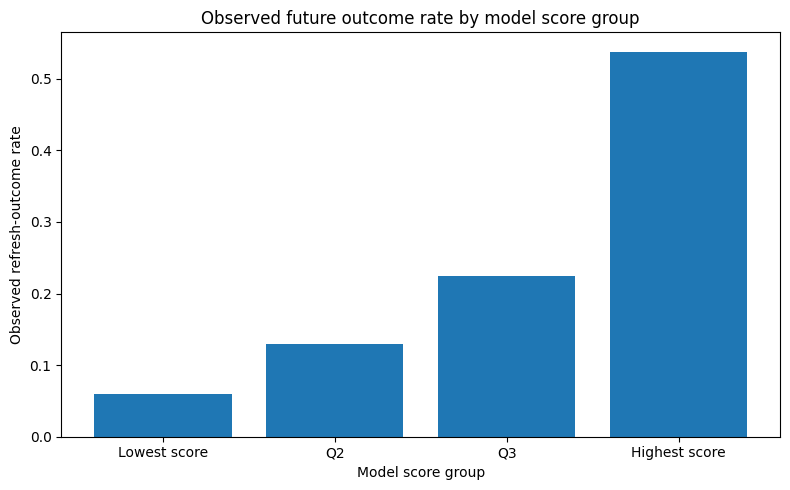

Saved: work/figures/capstone_score_quartiles.png


In [22]:
# ============================================================
# FIGURE — OUTCOME RATE BY MODEL SCORE QUARTILE
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    quartile_summary["score_quartile"].astype(str),
    quartile_summary["positive_rate"]
)

plt.ylabel("Observed refresh-outcome rate")
plt.xlabel("Model score group")
plt.title("Observed future outcome rate by model score group")

plt.tight_layout()

quartile_fig_path = FIGURE_DIR / "capstone_score_quartiles.png"

plt.savefig(
    quartile_fig_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", quartile_fig_path)

In [23]:
# ============================================================
# FEATURE IMPORTANCE — ONLY FOR TREE MODEL
# ============================================================

if selected_model_name == "Random Forest":

    rf_pipeline = final_model.named_steps["model"]

    importance_df = (
        pd.DataFrame({
            "feature": FEATURE_COLS,
            "importance": rf_pipeline.feature_importances_
        })
        .sort_values(
            "importance",
            ascending=False
        )
    )

    display(
        importance_df.head(15)
    )

else:

    importance_df = pd.DataFrame()

    print(
        "Primary model is Logistic Regression; "
        "tree feature importance is not applicable."
    )

,feature,importance
6,sessions_organic,0.279367
0,gsc_avg_position,0.184671
21,organic_session_share,0.180740
1,ga4_pageviews,0.083273
2,ga4_sessions,0.070168
3,ga4_users,0.063152
5,ga4_total_engagement_sec,0.040384
20,ga4_data_available,0.027145
23,avg_engagement_sec_per_session,0.017368
25,scroll_events_per_session,0.016260


### Feature-importance interpretation

Feature importance is used here as a diagnostic aid rather than causal evidence.

A highly ranked feature means that the model relied on that signal within the fitted dataset. It does not mean that changing that feature would cause the outcome to change.

In particular, no feature should be described as "causing" a refresh outcome based on this analysis.

## 5. Limitations

*What this work cannot claim.*

## 5. Limitations

This study has several important limitations.

### 1. Observational data

The analysis observes naturally occurring search and analytics behavior. It does not randomly assign content changes.

Therefore, the study cannot establish that refreshing a page causes better search performance.

### 2. Custom outcome definition

The refresh-review outcome is an operational research label:

- minimum feature-month impressions;
- measurable feature-month CTR;
- at least a 20% subsequent CTR decline.

It should not be treated as a universal definition of content decay.

### 3. Population selection

The evaluation requires a matching feature-month and outcome-month observation. Pages without a matching future observation are therefore excluded.

### 4. Limited time horizon

The final evaluation uses one future month-to-month window. Additional future windows are required before making stronger claims about stability.

### 5. Client heterogeneity

Clients differ in content, history, analytics coverage, and search behavior. A model that performs well in this dataset may not transfer to another portfolio.

### 6. Feature availability

GA4 availability differs across clients and time. Missingness and measurement availability can therefore affect the observed signals.

### 7. No causal refresh test

The study does not compare randomized refreshed and non-refreshed pages. Therefore, it cannot estimate the causal effect of refreshing.

### 8. No Google algorithm claim

The model ranks outcomes in the evaluated FlyRank dataset. It does not predict or reverse-engineer Google's ranking algorithm.

### Overall framing

The strongest defensible interpretation is:

> The experiment measures whether a leakage-aware, time-aware ranking can provide directional decision-support for prioritizing human content review in the evaluated dataset.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked recommendations

The model output is converted into a human-review queue.

The queue is deliberately framed as decision support:

> These pages appear worth reviewing first because they received higher model scores under the tested methodology.

The model does not automatically:

- publish content;
- rewrite content;
- delete pages;
- merge pages;
- change URLs;
- create redirects;
- modify canonical tags;
- modify robots directives;
- make legal, medical, financial, or brand-sensitive decisions.

A reviewer must inspect the page and its context before taking action.

In [24]:
# ============================================================
# REASON-CODE THRESHOLDS
# ============================================================

# Thresholds are estimated from PRE-TEST training data only.
# They are used for relative triage, not as causal rules.

position_p75 = train_df["gsc_avg_position"].quantile(0.75)

organic_sessions_p25 = train_df["sessions_organic"].quantile(0.25)

engagement_rate_p25 = train_df["engaged_session_rate"].quantile(0.25)

score_p90 = test_df["model_score"].quantile(0.90)
score_p75 = test_df["model_score"].quantile(0.75)

print("Training position P75:", position_p75)
print("Training organic sessions P25:", organic_sessions_p25)
print("Training engagement-rate P25:", engagement_rate_p25)

Training position P75: 17.052224025974027
Training organic sessions P25: 0.0
Training engagement-rate P25: 0.0


In [25]:
# ============================================================
# ACTION / REASON-CODE ENGINE
# ============================================================

def assign_reason_codes(row):
    reasons = []

    if row["model_score"] >= score_p90:
        reasons.append("TOP_MODEL_PRIORITY")

    elif row["model_score"] >= score_p75:
        reasons.append("HIGH_MODEL_PRIORITY")

    if (
        pd.notna(row["gsc_avg_position"])
        and row["gsc_avg_position"] >= position_p75
    ):
        reasons.append("WEAKER_SEARCH_VISIBILITY")

    if row["sessions_organic"] <= organic_sessions_p25:
        reasons.append("LOW_ORGANIC_ACTIVITY")

    if (
        pd.notna(row["engaged_session_rate"])
        and row["engaged_session_rate"] <= engagement_rate_p25
    ):
        reasons.append("LOW_ENGAGEMENT_SIGNAL")

    if row["ga4_data_available"] == 0:
        reasons.append("LIMITED_GA4_COVERAGE")

    if not reasons:
        reasons.append("MODEL_RANK_ONLY")

    return "|".join(reasons)


def assign_action(row):
    if row["model_score"] >= score_p90:
        return "PRIORITY_HUMAN_REVIEW"

    if row["model_score"] >= score_p75:
        return "REVIEW_IF_CAPACITY_ALLOWS"

    return "MONITOR"


test_df["reason_code"] = test_df.apply(
    assign_reason_codes,
    axis=1
)

test_df["recommended_action"] = test_df.apply(
    assign_action,
    axis=1
)

test_df["rank"] = (
    test_df["model_score"]
    .rank(
        ascending=False,
        method="first"
    )
    .astype(int)
)

test_df.sort_values("rank").head(20)

,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,ga4_total_engagement_sec,sessions_organic,sessions_direct,sessions_referral,sessions_social,sessions_paid,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,ga4_data_available,feature_month,organic_session_share,engaged_session_rate,avg_engagement_sec_per_session,ai_session_share,scroll_events_per_session,ctr,gsc_impressions_next,gsc_clicks_next,ctr_next,refresh_outcome,ctr_change_pct,baseline_score,model_score,score_quartile,reason_code,recommended_action,rank
12646,client_fef1a8f436438636,content_e74a879015e14fab,1493.0,6.0,8.199598,15.0,7.0,6.0,1.0,125.0,14.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,1,2026-03,2.000000,0.142857,17.857143,0.285714,0.142857,0.004019,1348.0,3.0,0.002226,1,-0.446217,2,0.680422,Highest score,TOP_MODEL_PRIORITY,PRIORITY_HUMAN_REVIEW,1
6212,client_fef1a8f436438636,content_09d2014d2f9ab014,3173.0,9.0,12.589663,28.0,14.0,13.0,1.0,229.0,22.0,2.0,5.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,2.0,1,2026-03,1.571429,0.071429,16.357143,0.357143,0.142857,0.002836,2255.0,2.0,0.000887,1,-0.687312,2,0.679652,Highest score,TOP_MODEL_PRIORITY,PRIORITY_HUMAN_REVIEW,2
27194,client_fef1a8f436438636,content_f42524faa69d2491,6173.0,5.0,33.748097,14.0,8.0,7.0,1.0,20.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2026-03,1.750000,0.125000,2.500000,0.000000,0.000000,0.000810,4531.0,5.0,0.001104,0,0.362392,2,0.679344,Highest score,TOP_MODEL_PRIORITY|WEAKER_SEARCH_VISIBILITY,PRIORITY_HUMAN_REVIEW,3
9864,client_fef1a8f436438636,content_a465c055eede03b9,2251.0,7.0,20.051977,21.0,10.0,10.0,1.0,81.0,19.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1,2026-03,1.900000,0.100000,8.100000,0.000000,0.300000,0.003110,1565.0,1.0,0.000639,1,-0.794523,2,0.678684,Highest score,TOP_MODEL_PRIORITY|WEAKER_SEARCH_VISIBILITY,PRIORITY_HUMAN_REVIEW,4
47472,client_f623b01661d4bfe4,content_90a46a0603e214cf,318.0,12.0,27.600629,29.0,13.0,13.0,1.0,55.0,25.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1,2026-03,1.923077,0.076923,4.230769,0.000000,0.153846,0.037736,87.0,3.0,0.034483,0,-0.086207,0,0.678638,Highest score,TOP_MODEL_PRIORITY|WEAKER_SEARCH_VISIBILITY,PRIORITY_HUMAN_REVIEW,5
101769,client_d211cb07b9059bab,content_dee34e8c8d6d3d34,984.0,10.0,13.693089,25.0,12.0,11.0,1.0,138.0,26.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1,2026-03,2.166667,0.083333,11.500000,0.000000,0.166667,0.010163,1531.0,12.0,0.007838,1,-0.228739,1,0.678042,Highest score,TOP_MODEL_PRIORITY,PRIORITY_HUMAN_REVIEW,6
42002,client_f623b01661d4bfe4,content_d51c6315f9c34ab0,524.0,4.0,34.001908,11.0,5.0,5.0,1.0,15.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2026-03,1.800000,0.200000,3.000000,0.000000,0.000000,0.007634,771.0,3.0,0.003891,1,-0.490272,2,0.677672,Highest score,TOP_MODEL_PRIORITY|WEAKER_SEARCH_VISIBILITY,PRIORITY_HUMAN_REVIEW,7
42029,client_f623b01661d4bfe4,content_af5331b6e87f7a37,1105.0,10.0,35.666063,34.0,13.0,12.0,1.0,200.0,26.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1,2026-03,2.000000,0.076923,15.384615,0.000000,0.230769,0.009050,1438.0,8.0,0.005563,1,-0.385257,2,0.677588,Highest score,TOP_MODEL_PRIORITY|WEAKER_SEARCH_VISIBILITY,PRIORITY_HUMAN_REVIEW,8
86934,client_fef1a8f436438636,content_101c4a5de4671453,1411.0,7.0,16.020553,17.0,8.0,8.0,1.0,119.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,2026-03,2.250000,0.125000,14.875000,0.000000,0.125000,0.004961,1166.0,1.0,0.000858,1,-0.827126,2,0.676362,Highest score,TOP_MODEL_PRIORITY,PRIORITY_HUMAN_REVIEW,9
86794,client_fef1a8f436438636,content_bd53d2bc50486194,1766.0,7.0,17.099094,14.0,7.0,7.0,2.0,102.0,16.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1,2026-03,2.285714,0.285714,14.571429,0.000000,0.428571,0.003964,1976.0,0.0,0.000000,1,-1.000000,2,0.675448,Highest score,TOP_MODEL_PRIORITY|WEAKER_SEARCH_VISIBILITY,PRIORITY_HUMAN_REVIE

### Content archetype → action mapping

The queue is supplemented with a simple signal-based archetype.

The archetype is not a learned causal category. It is a practical interpretation layer intended to help a reviewer understand why a high-ranked page may deserve attention.

In [26]:
# ============================================================
# ARCHETYPE MAPPING
# ============================================================

position_median = train_df["gsc_avg_position"].median()
organic_sessions_median = train_df["sessions_organic"].median()
engagement_median = train_df["engaged_session_rate"].median()


def assign_archetype(row):

    if row["ga4_data_available"] == 0:
        return "DATA_LIMITED"

    visible = (
        pd.notna(row["gsc_avg_position"])
        and row["gsc_avg_position"] <= position_median
    )

    organic = (
        row["sessions_organic"] >= organic_sessions_median
    )

    engaged = (
        pd.notna(row["engaged_session_rate"])
        and row["engaged_session_rate"] >= engagement_median
    )

    if visible and organic and engaged:
        return "VISIBLE_AND_ENGAGED"

    if visible and not engaged:
        return "VISIBLE_BUT_UNDER_ENGAGED"

    if not visible and organic:
        return "TRAFFIC_WITH_WEAKER_VISIBILITY"

    if not visible and not organic:
        return "LOW_VISIBILITY_LOW_TRAFFIC"

    return "MIXED_SIGNAL"


test_df["archetype"] = test_df.apply(
    assign_archetype,
    axis=1
)

archetype_actions = pd.DataFrame({
    "archetype": [
        "VISIBLE_AND_ENGAGED",
        "VISIBLE_BUT_UNDER_ENGAGED",
        "TRAFFIC_WITH_WEAKER_VISIBILITY",
        "LOW_VISIBILITY_LOW_TRAFFIC",
        "DATA_LIMITED",
        "MIXED_SIGNAL"
    ],
    "recommended_action": [
        "PROTECT_AND_MONITOR",
        "REVIEW_RELEVANCE_AND_PAGE_EXPERIENCE",
        "REVIEW_SEARCH_INTENT_AND_DISCOVERABILITY",
        "PRIORITIZE_CONTENT_REVIEW",
        "SEARCH_ONLY_REVIEW_OR_MONITOR",
        "HUMAN_REVIEW"
    ]
})

archetype_actions

,archetype,recommended_action
0,VISIBLE_AND_ENGAGED,PROTECT_AND_MONITOR
1,VISIBLE_BUT_UNDER_ENGAGED,REVIEW_RELEVANCE_AND_PAGE_EXPERIENCE
2,TRAFFIC_WITH_WEAKER_VISIBILITY,REVIEW_SEARCH_INTENT_AND_DISCOVERABILITY
3,LOW_VISIBILITY_LOW_TRAFFIC,PRIORITIZE_CONTENT_REVIEW
4,DATA_LIMITED,SEARCH_ONLY_REVIEW_OR_MONITOR
5,MIXED_SIGNAL,HUMAN_REVIEW


In [27]:
# ============================================================
# FINAL RESEARCH ACTION QUEUE
# ============================================================

queue_cols = [
    "rank",
    "model_score",
    "recommended_action",
    "reason_code",
    "archetype",

    "gsc_avg_position",
    "ga4_sessions",
    "sessions_organic",
    "engaged_session_rate",
    "organic_session_share",
    "ga4_data_available"
]

queue = (
    test_df[
        queue_cols
    ]
    .sort_values("rank")
    .reset_index(drop=True)
)

queue.head(25)

,rank,model_score,recommended_action,reason_code,archetype,gsc_avg_position,ga4_sessions,sessions_organic,engaged_session_rate,organic_session_share,ga4_data_available
0,1,0.680422,PRIORITY_HUMAN_REVIEW,TOP_MODEL_PRIORITY,VISIBLE_AND_ENGAGED,8.199598,7.0,14.0,0.142857,2.000000,1
1,2,0.679652,PRIORITY_HUMAN_REVIEW,TOP_MODEL_PRIORITY,TRAFFIC_WITH_WEAKER_VISIBILITY,12.589663,14.0,22.0,0.071429,1.571429,1
2,3,0.679344,PRIORITY_HUMAN_REVIEW,TOP_MODEL_PRIORITY|WEAKER_SEARCH_VISIBILITY,TRAFFIC_WITH_WEAKER_VISIBILITY,33.748097,8.0,14.0,0.125000,1.750000,1
3,4,0.678684,PRIORITY_HUMAN_REVIEW,TOP_MODEL_PRIORITY|WEAKER_SEARCH_VISIBILITY,TRAFFIC_WITH_WEAKER_VISIBILITY,20.051977,10.0,19.0,0.100000,1.900000,1
4,5,0.678638,PRIORITY_HUMAN_REVIEW,TOP_MODEL_PRIORITY|WEAKER_SEARCH_VISIBILITY,TRAFFIC_WITH_WEAKER_VISIBILITY,27.600629,13.0,25.0,0.076923,1.923077,1
5,6,0.678042,PRIORITY_HUMAN_REVIEW,TOP_MODEL_PRIORITY,TRAFFIC_WITH_WEAKER_VISIBILITY,13.693089,12.0,26.0,0.083333,2.166667,1
6,7,0.677672,PRIORITY_HUMAN_REVIEW,TOP_MODEL_PRIORITY|WEAKER_SEARCH_VISIBILITY,TRAFFIC_WITH_WEAKER_VISIBILITY,34.001908,5.0,9.0,0.200000,1.800000,1
7,8,0.677588,PRIORITY_HUMAN_REVIEW,TOP_MODEL_PRIORITY|WEAKER_SEARCH_VISIBILITY,TRAFFIC_WITH_WEAKER_VISIBILITY,35.666063,13.0,26.0,0.076923,2.000000,1
8,9,0.676362,PRIORITY_HUMAN_REVIEW,TOP_MODEL_PRIORITY,TRAFFIC_WITH_WEAKER_VISIBILITY,16.020553,8.0,18.0,0.125000,2.250000,1
9,10,0.675448,PRIORITY_HUMAN_REVIEW,TOP_MODEL_PRIORITY|WEAKER_SEARCH_VISIBILITY,TRAFFIC_WITH_WEAKER_VISIBILITY,17.099094,7.0,16.0,0.285714,2.285714,1


### Cost/value thinking

No production cost, revenue, or editorial labor estimates are available in this study. I therefore do not assign fabricated monetary values.

Instead, the queue uses a qualitative cost/value framework:

| Priority | Expected review value | Review cost | Suggested treatment |
|---|---|---|---|
| Priority human review | Higher | Human review required | Review first |
| Review if capacity allows | Moderate | Human review required | Batch review |
| Monitor | Unclear/lower | Avoid unnecessary work | Revisit later |

The purpose of the ranking is therefore to allocate limited human attention, not to automatically decide which content should be changed.

## Human review protocol

Before acting on a high-ranked recommendation, a reviewer should check:

1. Does the page's search intent still match the query/topic it is intended to serve?
2. Is the content factually current?
3. Is the page still strategically important?
4. Are there competing pages covering the same intent?
5. Are there technical/indexing issues that could explain weak visibility?
6. Is the page affected by a seasonal or temporary demand pattern?
7. Is the observed signal supported by enough data?
8. Would editing the page create a new risk or remove useful information?

### No-go cases

The model must not automatically:

- delete content;
- merge URLs;
- publish rewritten content;
- change canonical URLs;
- create redirects;
- modify robots directives;
- make legal or compliance decisions;
- make sensitive health or financial content decisions;
- overwrite brand-critical content;
- declare that a page "will recover" after refresh;
- claim that a content change will improve Google rankings.

The system is a prioritization aid. Human judgment remains responsible for the action.

## Monitoring and retrain triggers

The recommendation system should be treated as a model that can become stale.

### Proposed monitoring cadence

Re-evaluate the ranking whenever a new labeled month becomes available.

### Trigger a model review when:

- Average Precision falls materially below the original future-test reference;
- Precision@K no longer provides useful concentration relative to the base rate;
- the model no longer outperforms the fixed baseline;
- feature distributions shift substantially from the training period;
- missingness or data-availability patterns change;
- the content population changes materially;
- the definition of the refresh-review outcome changes.

### Retraining rule

Retraining should occur only after a new labeled time window becomes available.

The model should not be retrained simply because its ranking "looks wrong" on a few individual pages.

### Important limitation

These thresholds are proposed monitoring rules rather than empirically calibrated production thresholds. A production monitoring policy would require a longer historical evaluation and operational data.

In [28]:
# ============================================================
# MONITORING RECEIPT
# ============================================================

reference_ap = model_results["average_precision"]
reference_p50 = model_results["precision_at_50"]

monitoring_receipt = {
    "reference_test_average_precision": reference_ap,
    "reference_test_precision_at_50": reference_p50,
    "reference_test_base_rate": float(y_test.mean()),
    "selected_model": selected_model_name,
    "future_test_period": "2026-03 → 2026-04",
    "proposed_review_trigger": (
        "Re-evaluate when a new labeled month is available; "
        "review the model if performance no longer beats the baseline "
        "or if data/population characteristics materially change."
    )
}

monitoring_receipt

{'reference_test_average_precision': 0.48077158171749074,
 'reference_test_precision_at_50': 0.72,
 'reference_test_base_rate': 0.23737771919091258,
 'selected_model': 'Random Forest',
 'future_test_period': '2026-03 → 2026-04',
 'proposed_review_trigger': 'Re-evaluate when a new labeled month is available; review the model if performance no longer beats the baseline or if data/population characteristics materially change.'}

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## 7. Artifacts the paper embeds

The capstone produces the following research artifacts:

### Metrics

`work/metrics/capstone_metrics.json`

Contains the model-selection information, final future-test metrics, base rate, top-K results, and score-group summary.

### Ranked queue

`work/outputs/capstone_ranked_action_queue.csv`

Contains the regenerated research action queue.

This file is intentionally not treated as a public client export.

### Paper summary

`work/outputs/capstone_summary.json`

Contains the core research question, decision framing, validation periods, selected model, and interpretation.

### Figure

`work/figures/capstone_score_quartiles.png`

Shows the observed outcome rate across model-score groups.

These artifacts are designed to make the final paper traceable to the notebook rather than requiring manually copied numbers.

In [29]:
# ============================================================
# EXPORT METRICS
# ============================================================

metrics_payload = {
    "selected_model": selected_model_name,
    "training_periods": [
        "2026-01 → 2026-02",
        "2026-02 → 2026-03"
    ],
    "future_test_period": "2026-03 → 2026-04",
    "feature_count": len(FEATURE_COLS),
    "features_excluded_for_leakage": [
        "gsc_impressions",
        "gsc_clicks",
        "ctr"
    ],
    "results": results_df.to_dict(orient="records"),
    "lift_table": lift_table.to_dict(orient="records"),
    "quartile_summary": quartile_summary.to_dict(orient="records")
}

metrics_path = METRIC_DIR / "capstone_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(
        metrics_payload,
        f,
        indent=2
    )

print("Saved:", metrics_path)

Saved: work/metrics/capstone_metrics.json


In [30]:
# ============================================================
# EXPORT RANKED QUEUE
# ============================================================

queue_path = OUTPUT_DIR / "capstone_ranked_action_queue.csv"

queue.to_csv(
    queue_path,
    index=False
)

print("Saved:", queue_path)
print("Rows:", len(queue))

Saved: work/outputs/capstone_ranked_action_queue.csv
Rows: 158549


In [31]:
# ============================================================
# EXPORT RANKED QUEUE
# ============================================================

queue_path = OUTPUT_DIR / "capstone_ranked_action_queue.csv"

queue.to_csv(
    queue_path,
    index=False
)

print("Saved:", queue_path)
print("Rows:", len(queue))

Saved: work/outputs/capstone_ranked_action_queue.csv
Rows: 158549


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


In [32]:
# ============================================================
# FINAL SELF-CHECK
# ============================================================

checks = {
    "question_defined": True,
    "warehouse_verified": len(warehouse_check) == 1,
    "grain_checked": len(grain_probe) == 0,
    "target_created": "refresh_outcome" in mar_apr.columns,
    "forbidden_features_excluded": len(overlap) == 0,
    "time_aware_test_used": True,
    "client_grouped_internal_validation": True,
    "baseline_evaluated": True,
    "model_evaluated": True,
    "base_rate_reported": True,
    "ranked_queue_created": len(queue) > 0,
    "metrics_exported": metrics_path.exists(),
    "queue_exported": queue_path.exists(),
    "figure_exported": quartile_fig_path.exists(),
    "claims_are_non_causal": True
}

self_check = pd.DataFrame(
    [
        {
            "check": key,
            "status": "PASS" if value else "FAIL"
        }
        for key, value in checks.items()
    ]
)

self_check

,check,status
0,question_defined,PASS
1,warehouse_verified,PASS
2,grain_checked,PASS
3,target_created,PASS
4,forbidden_features_excluded,PASS
5,time_aware_test_used,PASS
6,client_grouped_internal_validation,PASS
7,baseline_evaluated,PASS
8,model_evaluated,PASS
9,base_rate_reported,PASS


## Final conclusion

This capstone developed a leakage-aware content-refresh opportunity ranking using real FlyRank search and analytics data.

The model was trained on earlier month-to-month observations and evaluated on a later future window. The final model excludes variables that directly participate in the target definition, addressing the label-derived leakage identified during the earlier validation audit.

The resulting ranking is intended as decision support: it helps a human reviewer decide where to look first.

The evidence is directional and observational. It does not demonstrate that refreshing a page causes improved performance, and it does not predict Google's ranking algorithm.

The most defensible outcome of the project is therefore a reproducible methodology for turning historical search signals into a ranked, human-reviewed content investigation queue.